# AI Memory Tool Comparison

This notebook benchmarks four memory layers for LLM applications — Zep, mem0, Supermemory, and Cognee — across setup, ingestion, and retrieval. The comparison is scoped to free-tier, beginner-friendly configurations, so results reflect what a developer gets without hitting a paywall, not each provider's full feature set.

Input data and retrieval tasks are held constant across all four providers to isolate differences in memory architecture rather than dataset artifacts. Each provider requires its own API key, set in a local `.env` file before running the notebook.

---

### Before you run this notebook

- [ ] **API keys**: create a `.env` file in this notebook's directory with `ZEP_API_KEY`, `MEM0_API_KEY`, `SUPERMEMORY_API_KEY`, `COGNEE_API_KEY`, `COGNEE_URL`, and `OPENAI_API_KEY`.
- [ ] **Data path**: in section 2a ("Loading shared dataset"), update `DATA_ROOT` to point at your local copy of the `deterministic/` and `non_deterministic/` folders.

---


## Contents

**1. [Download & Setup](#1-download--setup)**
   - [Zep](#zep-installation)
   - [mem0](#mem0-installation)
   - [Supermemory](#supermemory-installation)
   - [Cognee](#cognee-installation)

**2. [Data Ingestion](#2-data-ingestion)**
   - [a. Loading shared dataset](#2a-loading-shared-dataset)
   - [b. Ingestion per provider](#2b-ingestion-for-each-provider)

**3. [Retrieval & Evaluation](#3-retrieval--eval)**
   - [a. Ground-truth QA](#a-ground-truth-qa) — absolute truth, temporal, conflict resolution, multi-hop
   - [b. Ambiguity & contradiction handling](#b-ambiguity--contradiction-handling)
   - [c. Needle in haystack](#c-needle-in-haystack)
   - [d. Run evaluations](#d-run-evaluations)
   - [e. Manual spot-check](#f-manual-spot-check)
   - [f. Metrics & comparison](#e-metrics--comparison)

---

## 1. Download & Setup

Each provider's setup ships with a basic ingestion/retrieval smoke test; those are omitted here to keep this section focused on installation and configuration.

### Zep Installation

In [ ]:
%pip install zep-cloud
%pip install python-dotenv
import os
import uuid
from dotenv import load_dotenv
from zep_cloud.client import Zep
from zep_cloud.types import Message

load_dotenv()
zep_client = Zep(api_key=os.getenv("ZEP_API_KEY"))


### mem0 Installation

In [ ]:
%pip install mem0ai
%pip install python-dotenv
%pip install mem0ai[nlp]
%pip install "mem0ai[extras]"
import os
from dotenv import load_dotenv
from mem0 import MemoryClient

load_dotenv()
mem0_client = MemoryClient(api_key=os.getenv("MEM0_API_KEY"))


### Supermemory Installation


In [ ]:
%pip install supermemory
import os
from supermemory import Supermemory
from dotenv import load_dotenv


load_dotenv()
sm_client = Supermemory(api_key=os.getenv("SUPERMEMORY_API_KEY"))


### Cognee Installation

In [ ]:
%pip install cognee
import os
from dotenv import load_dotenv
import cognee

load_dotenv()

async def main():
    await cognee.serve(
        url=os.getenv("COGNEE_URL"),
        api_key=os.getenv("COGNEE_API_KEY")
    )

await main()


## 2. Data Ingestion

The shared dataset is loaded once, then ingested into each provider individually. After each ingestion, we run a quick check to confirm the data landed correctly before moving on to Section 3: Retrieval & Evaluation.

Shared dataset structure:

```
memory_provider_eval/
├── README.md
├── memory_provider_comparison.ipynb
├── deterministic/
│   ├── spec.json
│   ├── documents/              (15 .md files)
│   └── ground_truth_qa.json
└── non_deterministic/
    ├── index.json
    ├── persona-01_priya.json ... persona-11_ravi.json
    └── README.md
```

### 2.a Loading shared dataset

In [5]:
import glob
import json
import os
from pathlib import Path


#replace with own path to data root
DATA_ROOT = Path.cwd()

DET_DIR = os.path.join(DATA_ROOT, "deterministic")
DET_DOC_PATHS = sorted(glob.glob(os.path.join(DET_DIR, "documents", "*.md")))
DET_DOCS = []
for p in DET_DOC_PATHS:
    with open(p) as f:
        DET_DOCS.append({"filename": os.path.basename(p), "text": f.read()})

with open(os.path.join(DET_DIR, "ground_truth_qa.json")) as f:
    DET_QA = json.load(f)

ND_DIR = os.path.join(DATA_ROOT, "non_deterministic")
ND_PATHS = sorted(glob.glob(os.path.join(ND_DIR, "persona-*.json")))
ND_DOCS = []
for p in ND_PATHS:
    with open(p) as f:
        ND_DOCS.append(json.load(f))

print(f"Loaded {len(DET_DOCS)} deterministic documents, {len(DET_QA)} deterministic QA pairs")
print(f"Loaded {len(ND_DOCS)} custom contradiction personas")

Loaded 15 deterministic documents, 29 deterministic QA pairs
Loaded 11 custom contradiction personas


### 2.b Ingestion for each provider

In this order:
1. Zep
2. mem0
3. Supermemory
5. Cognee

In [6]:
from zep_cloud.client import Zep
from zep_cloud.types import Message
from zep_cloud.core.api_error import ApiError

zep_client = Zep(api_key=os.environ["ZEP_API_KEY"])

def _ensure_user(user_id, first_name, last_name):
    try:
        zep_client.user.add(user_id=user_id, first_name=first_name, last_name=last_name)
    except ApiError as e:
        if "already exists" not in str(e.body):
            raise
def _role_for_speaker(speaker, persona_name):
    return "user" if speaker == persona_name else "assistant"

def _ensure_thread(thread_id, user_id):
    try:
        zep_client.thread.create(thread_id=thread_id, user_id=user_id)
    except ApiError as e:
        if "already exists" not in str(e.body):
            raise

def zep_ingest_documents():
    _ensure_user("solvane_docs", "Solvane", "Docs")
    for doc in DET_DOCS:
        zep_client.graph.add(user_id="solvane_docs", type="text", data=doc["text"])

def zep_ingest_conversations():
    for persona in ND_DOCS:
        user_id = persona["persona_id"]
        persona_name = persona["persona_name"]
        _ensure_user(user_id, persona_name.split()[0], "Persona")
        for session in persona["sessions"]:
            thread_id = f"{persona['persona_id']}_{session['session_id']}"
            _ensure_thread(thread_id, user_id)
            messages = [
                Message(
                    name=t["speaker"],
                    content=t["text"],
                    role=_role_for_speaker(t["speaker"], persona_name),
                )
                for t in session["turns"]
                if t["text"] != "PLACEHOLDER_RESPONSE_TO_EVALUATE"
            ]
            if messages:
                zep_client.thread.add_messages(thread_id=thread_id, messages=messages)

zep_ingest_documents()
zep_ingest_conversations()

print(f"Zep ingestion complete: {len(DET_DOCS)} documents and {len(ND_DOCS)} personas loaded")



Zep ingestion complete: 15 documents and 11 personas loaded


In [7]:
from mem0 import MemoryClient
import os
from dotenv import load_dotenv

load_dotenv()
mem0_client = MemoryClient(api_key=os.getenv("MEM0_API_KEY"))

def mem0_ingest_documents():
    for doc in DET_DOCS:
        mem0_client.add(
            user_id="solvane_docs",
            run_id="solvane_docs_thread",
            messages=[{"role": "system", "content": doc["text"]}],
        )

def mem0_ingest_conversations():
    for persona in ND_DOCS:
        user_id = persona["persona_id"]
        for session in persona["sessions"]:
            run_id = f"{persona['persona_id']}_{session['session_id']}"
            messages = [
                {"role": t["speaker"], "content": t["text"]}
                for t in session["turns"] if t["text"] != "PLACEHOLDER_RESPONSE_TO_EVALUATE"
            ]
            if messages:
                mem0_client.add(user_id=user_id, run_id=run_id, messages=messages)

mem0_ingest_documents()
mem0_ingest_conversations()

print(f"mem0 ingestion complete: {len(DET_DOCS)} documents and {len(ND_DOCS)} personas loaded")


mem0 ingestion complete: 15 documents and 11 personas loaded


In [8]:
from supermemory import Supermemory
import os
from dotenv import load_dotenv

load_dotenv()
sm_client = Supermemory(api_key=os.getenv("SUPERMEMORY_API_KEY"))

def supermemory_ingest_documents():
    for doc in DET_DOCS:
        sm_client.add(content=doc["text"], container_tag="solvane_docs")

def supermemory_ingest_conversations():
    for persona in ND_DOCS:
        tag = persona["persona_id"]
        for session in persona["sessions"]:
            for t in session["turns"]:
                if t["text"] == "PLACEHOLDER_RESPONSE_TO_EVALUATE":
                    continue
                sm_client.add(content=f"{t['speaker']}: {t['text']}", container_tag=tag)

supermemory_ingest_documents()
supermemory_ingest_conversations()

print(f"Supermemory ingestion complete: {len(DET_DOCS)} documents and {len(ND_DOCS)} personas loaded")


Supermemory ingestion complete: 15 documents and 11 personas loaded


In [ ]:
import os
import cognee

async def cognee_ingest_documents():
    for doc in DET_DOCS:
        await cognee.remember(
            f"[{doc['filename']}]\n{doc['text']}",
            dataset_name="solvane_docs",
        )

async def cognee_ingest_conversations():
    for persona in ND_DOCS:
        for session in persona["sessions"]:
            for turn in session["turns"]:
                if turn["text"] == "PLACEHOLDER_RESPONSE_TO_EVALUATE":
                    continue
                await cognee.remember(
                    f"[{persona['persona_id']} / {session['session_id']} / {session['date']}] "
                    f"{turn['speaker']}: {turn['text']}",
                    dataset_name=persona["persona_id"],
                )
                
await cognee.serve(
    url=os.getenv("COGNEE_URL"),
    api_key=os.getenv("COGNEE_API_KEY"),
)

await cognee_ingest_documents()
await cognee_ingest_conversations()

print(f"Cognee ingestion complete: {len(DET_DOCS)} documents and {len(ND_DOCS)} personas loaded")


Confirm data ingestion actually landed and is queryable:

Several of these providers build their memory representation (graph edges, embeddings, indices) asynchronously after an add/remember call returns, so the call finishing without an error doesn't guarantee the data is queryable yet. Querying too soon after ingestion is a plausible source of run-to-run variance in the results below (a provider that hasn't finished indexing looks worse than one queried a minute later, even on identical data, independent of any LLM temperature setting). The cell below polls each provider a few times with a short wait between attempts, rather than checking once and moving on.

In [10]:
import time
import asyncio

_CHECK_PERSONA = ND_DOCS[0]["persona_id"]  # representative sample, not exhaustive over all 11

def _poll_until_nonzero(label, check_fn, attempts=4, delay=5):
    for attempt in range(attempts):
        try:
            count = check_fn()
        except Exception as exc:
            count = None
            print(f"  {label}: ERROR on attempt {attempt + 1}/{attempts} -- {exc}")
        else:
            if count and count > 0:
                suffix = "" if attempt == 0 else f" (took {attempt + 1} attempts)"
                print(f"  {label}: OK -- queryable{suffix}")
                return True
            print(f"  {label}: not yet queryable (attempt {attempt + 1}/{attempts}), retrying...")
        if attempt < attempts - 1:
            time.sleep(delay)
    print(f"  {label}: WARNING -- still not queryable after {attempts} attempts x {delay}s. "
          f"Ingestion may not have finished indexing, or didn't actually land.")
    return False

async def _poll_until_nonzero_async(label, check_fn, attempts=4, delay=5):
    for attempt in range(attempts):
        try:
            count = await check_fn()
        except Exception as exc:
            count = None
            print(f"  {label}: ERROR on attempt {attempt + 1}/{attempts} -- {exc}")
        else:
            if count and count > 0:
                suffix = "" if attempt == 0 else f" (took {attempt + 1} attempts)"
                print(f"  {label}: OK -- queryable{suffix}")
                return True
            print(f"  {label}: not yet queryable (attempt {attempt + 1}/{attempts}), retrying...")
        if attempt < attempts - 1:
            await asyncio.sleep(delay)
    print(f"  {label}: WARNING -- still not queryable after {attempts} attempts x {delay}s. "
          f"Ingestion may not have finished indexing, or didn't actually land.")
    return False

print("--- Zep ---")
for uid in ["solvane_docs", _CHECK_PERSONA]:
    _poll_until_nonzero(uid, lambda uid=uid: len(
        zep_client.graph.search(user_id=uid, query="summary", scope="edges", limit=3).edges
    ))

print("--- mem0 ---")
for uid in ["solvane_docs", _CHECK_PERSONA]:
    _poll_until_nonzero(uid, lambda uid=uid: len(
        mem0_client.search("What do you know so far?", filters={"user_id": uid})["results"]
    ))

print("--- Supermemory ---")
for tag in ["solvane_docs", _CHECK_PERSONA]:
    _poll_until_nonzero(tag, lambda tag=tag: len(
        sm_client.search.memories(q=tag, container_tag=tag, search_mode="hybrid", threshold=0, limit=5).results
    ))

print("--- Cognee ---")
async def _cognee_count(dataset_name):
    results = await cognee.recall(query_text="summary", datasets=[dataset_name], only_context=True)
    if isinstance(results, str):
        return 1 if results.strip() else 0
    return len(results) if results else 0

for dataset_name in ["solvane_docs", _CHECK_PERSONA]:
    await _poll_until_nonzero_async(dataset_name, lambda dataset_name=dataset_name: _cognee_count(dataset_name))

--- Zep ---
  solvane_docs: OK -- queryable
  persona-01: OK -- queryable
--- mem0 ---
  solvane_docs: OK -- queryable
  persona-01: OK -- queryable
--- Supermemory ---
  solvane_docs: OK -- queryable
  persona-01: OK -- queryable
--- Cognee ---
  solvane_docs: OK -- queryable
  persona-01: OK -- queryable


### 3. Retrieval & Eval

With data ingested across all four providers, we query each system with three independent evaluation sets: deterministic ground-truth QA, ambiguous/contradictory persona probes, and needle-in-haystack recall. The per-provider query functions defined below (`zep_ask`, `mem0_ask`, `supermemory_ask`, `cognee_ask`) are shared across all three: they route every answer through one shared `_synthesize` call, switched between a "resolve" and "hedge" system prompt depending on which section is calling it (see note below).

#### a. Ground-Truth QA

Questions from `ground_truth_qa.json`, each with one defined correct answer. Automatically split by type into: plain factual recall, temporal reasoning (facts that change over time), conflict resolution (superseded facts as of a given date), and multi-hop reasoning.

### Retrieval + synthesis, shared across sections (a)-(c)
Each `*_ask` function wraps that provider's native retrieval call, then routes the result through `_synthesize`. This synthesis step is what's actually graded, not raw memory output, so all four providers are judged on the same basis.

`_synthesize` runs in one of two modes, toggled by the global `_SYNTHESIS_MODE`:
- **resolve** (default, used in sections a and c): instructs the model to commit to one answer, picking the fact valid at the target date if several conflict. Every question here has one correct answer, so hedging would itself be a wrong answer.
- **hedge** (set only inside `evaluate_ambiguity`/`evaluate_ambiguity_async`, section b): instructs the model to surface unresolved contradictions instead of silently picking a side.

In [11]:
import os
from openai import OpenAI
import re
import time


_llm = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
_DATE_CLAUSE_RE = re.compile(r"\s*as of \d{4}-\d{2}-\d{2}\??", re.IGNORECASE)

# _SYNTHESIS_MODE controls which system prompt _synthesize uses
_SYNTHESIS_MODE = "resolve"

_RESOLVE_SYSTEM_PROMPT = (
    "Answer using ONLY the facts listed below. Facts may include a validity range "
    "like '(valid: DATE to DATE)' where 'present/current' means still true. Ignore "
    "today's real-world date. If facts conflict, pick the one valid at the target date. "
    "Be concise: state just the answer.\n\n"
    "Special case: if the question asks what a specific past document, snapshot, or "
    "report stated (e.g. 'according to the April 2024 org snapshot...') AND whether that "
    "is 'still accurate' or 'still true', answer BOTH parts: (1) what the fact was at "
    "that past point in time, and (2) whether it has since been superseded -- citing the "
    "newer fact if so. Do not just give the current state; the question is explicitly "
    "asking you to compare the historical claim against the current one."
)

_HEDGE_SYSTEM_PROMPT = (
    "Answer using ONLY the facts listed below. Some of these facts may be genuinely "
    "ambiguous or contradictory with no resolution given -- do not invent one. If the facts "
    "conflict and nothing in them tells you which one is current or correct, say so "
    "explicitly and present both sides rather than confidently picking one. If the facts "
    "are not actually in conflict, or an explicit resolution IS given (e.g. a later fact "
    "that plainly supersedes an earlier one), answer directly and do not hedge unnecessarily."
)

# --- Retry-with-backoff for every external network call -------------------
# This notebook makes a very large number of sequential live API calls (OpenAI +
# whichever provider is under test). A single transient timeout/connection error used to
# crash the entire run_and_log cell partway through, losing every provider that hadn't run
# yet. _with_retries / _with_retries_async retry on timeout/connection-shaped errors with
# exponential backoff (2s, 4s, 8s) before giving up. Tune max_attempts/base_delay if your
# network or a specific provider is consistently slower than this.
def _is_retryable(exc):
    msg = str(exc).lower()
    return any(s in msg for s in ("timeout", "timed out", "connection", "temporarily unavailable"))

def _with_retries(fn, *args, max_attempts=4, base_delay=2, **kwargs):
    last_exc = None
    for attempt in range(max_attempts):
        try:
            return fn(*args, **kwargs)
        except Exception as exc:
            last_exc = exc
            if not _is_retryable(exc) or attempt == max_attempts - 1:
                raise
            wait = base_delay * (2 ** attempt)
            print(f"  [retry] {type(exc).__name__}: {exc} -- attempt {attempt + 1}/{max_attempts}, retrying in {wait}s")
            time.sleep(wait)
    raise last_exc

async def _with_retries_async(fn, *args, max_attempts=4, base_delay=2, **kwargs):
    import asyncio
    last_exc = None
    for attempt in range(max_attempts):
        try:
            return await fn(*args, **kwargs)
        except Exception as exc:
            last_exc = exc
            if not _is_retryable(exc) or attempt == max_attempts - 1:
                raise
            wait = base_delay * (2 ** attempt)
            print(f"  [retry] {type(exc).__name__}: {exc} -- attempt {attempt + 1}/{max_attempts}, retrying in {wait}s")
            await asyncio.sleep(wait)
    raise last_exc

def _strip_date_clause(question):
    return _DATE_CLAUSE_RE.sub("", question).strip()

def _synthesize(question, snippets, query_date=None):
    if isinstance(snippets, str):
        context = snippets or "(no facts retrieved)"
    else:
        context = "\n".join(f"- {s}" for s in snippets) if snippets else "(no facts retrieved)"

    date_note = (f"\n\nAnswer as of: {query_date}." if query_date
                 else "\n\nNo date given -- answer with the current/most recent state.")

    system_prompt = _HEDGE_SYSTEM_PROMPT if _SYNTHESIS_MODE == "hedge" else _RESOLVE_SYSTEM_PROMPT

    resp = _with_retries(
        _llm.chat.completions.create,
        model="gpt-4o-mini",
        temperature=0,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Facts:\n{context}\n\nQuestion: {question}{date_note}"},
        ],
    )
    return resp.choices[0].message.content.strip()


def mem0_ask(question, query_date=None, user_id="solvane_docs"):
    search_query = _strip_date_clause(question)
    results = _with_retries(mem0_client.search, search_query, filters={"user_id": user_id})
    snippets = [r["memory"] for r in results["results"]]
    return _synthesize(question, snippets, query_date)

def zep_ask(question, query_date=None, user_id="solvane_docs"):
    search_query = _strip_date_clause(question)
    thread_id = f"eval-{uuid.uuid4().hex}"
    _with_retries(zep_client.thread.create, thread_id=thread_id, user_id=user_id)
    _with_retries(
        zep_client.thread.add_messages,
        thread_id,
        messages=[Message(name="Evaluator", role="user", content=search_query)],
    )

    ctx = _with_retries(zep_client.thread.get_user_context, thread_id=thread_id)
    return _synthesize(question, ctx.context, query_date)


def supermemory_ask(question, query_date=None, tag="solvane_docs"):
    search_query = _strip_date_clause(question)
    r = _with_retries(
        sm_client.search.memories,
        q=search_query, container_tag=tag, search_mode="hybrid", threshold=0, limit=10,
    )
    snippets = [res.memory or res.chunk for res in r.results]
    return _synthesize(question, snippets, query_date)


#### Grading utilities

`ask_safe`: catches provider errors so one failure doesn't kill the run <br>

`llm_judge`: grades free-text answers when they don't match the reference verbatim <br>

`_contains_whole`: word-boundary substring check used before falling back to `llm_judge`. A plain `in` check would let a wrong answer like "75 kg" pass when the reference is "5 kg", since the shorter string sits inside the longer one <br>

`CATEGORY_BY_TYPE`: buckets each ground-truth question into Temporal / Conflict Resolution / Multi-hop <br>

These four are reused in section (c); `evaluate_provider` below is the only part specific to ground-truth QA.

**Limitation:** the same model family (gpt-4o-mini) both answers questions (via `_synthesize`) and grades them (via `llm_judge` / `annotation_judge`). That's a self-grading setup, see section (f) for a manual spot-check sample to validate the judge isn't rubber-stamping itself.

In [12]:
from collections import defaultdict
import re

CATEGORY_BY_TYPE = {
    "as_of": "Temporal Reasoning",
    "current_undated": "Conflict Resolution",
    "multi_hop": "Multi-hop Reasoning",
    "distractor_check": "Multi-hop Reasoning",
}

def normalize_answer(text):
    return " ".join(str(text or "").strip().lower().split())

def _contains_whole(needle, haystack):
    """Word-boundary substring check. Plain `in` would match '5 kg' inside '75 kg' or '15 kg';
    this requires the needle to sit on a word boundary on both sides."""
    if not needle:
        return False
    pattern = r"(?<!\w)" + re.escape(needle) + r"(?!\w)"
    return re.search(pattern, haystack) is not None

def ask_safe(question, query_date, ask_fn, *extra_args):
    try:
        return str(ask_fn(question, query_date, *extra_args))
    except Exception as exc:
        return f"<ERROR: {exc}>"

async def ask_safe_async(question, query_date, ask_fn, *extra_args):
    try:
        return str(await ask_fn(question, query_date, *extra_args))
    except Exception as exc:
        return f"<ERROR: {exc}>"

def llm_judge(question, expected, got):
    try:
        resp = _with_retries(
            _llm.chat.completions.create,
            model="gpt-4o-mini",
            temperature=0,
            messages=[
                {"role": "system", "content": (
                    "Grade a candidate answer against a reference answer. Mark CORRECT if the "
                    "candidate's core factual claim matches the reference — even if phrased very "
                    "differently, more verbosely, with extra true context, or using equivalent "
                    "wording/units (e.g. '$150 per seat per month' = '$150/seat/month'; 'Tuesday to "
                    "Thursday' = 'Tue/Wed/Thu').\n"
                    "Do not penalize: paraphrase, extra correct detail, or additional caveats/exceptions "
                    "that coexist with the core claim without contradicting it (e.g. if the reference says "
                    "'3 days/week in office (Tue/Wed/Thu)' and the candidate adds 'Monday and Friday are "
                    "remote-flexible, with full-remote by manager exception,' that is CORRECT — it doesn't "
                    "change the number of in-office days or which days they are).\n"
                    "Mark INCORRECT only if the candidate: states a different fact/value than the "
                    "reference, changes the specific number/days/amount the reference commits to, omits "
                    "part of a multi-part reference answer, actually contradicts the reference, or claims "
                    "no information when the reference has a specific answer.\n"
                    "Respond in exactly this format:\n"
                    "VERDICT: CORRECT or INCORRECT\n"
                    "REASON: one short sentence"
                )},
                {"role": "user", "content": f"Question: {question}\nReference answer: {expected}\nCandidate answer: {got}"},
            ],
        )
    except Exception as exc:
        # Retries exhausted -- don't crash the whole evaluate_provider loop over one
        # stubborn timeout. Marked as a distinguishable FAIL so it's easy to filter out
        # of the accuracy numbers rather than silently counting as a real wrong answer.
        return False, f"<JUDGE_ERROR: {exc}>"

    text = resp.choices[0].message.content.strip()
    verdict_line = next((l for l in text.splitlines() if l.upper().startswith("VERDICT")), "")
    reason_line = next((l for l in text.splitlines() if l.upper().startswith("REASON")), "")
    is_correct = "CORRECT" in verdict_line.upper() and "INCORRECT" not in verdict_line.upper()
    return is_correct, reason_line.split(":", 1)[-1].strip()

def qa_category(qa):
    return CATEGORY_BY_TYPE.get(qa["type"], "Other")


def evaluate_provider(name, ask_fn):
    correct = 0
    cat_correct, cat_total = defaultdict(int), defaultdict(int)

    for qa in DET_QA:
        question, query_date = qa["question"], qa.get("query_date")
        display_q = f"{question} (Answer as of {query_date})" if query_date else question

        answer = ask_safe(question, query_date, ask_fn)
        norm_answer, norm_expected = normalize_answer(answer), normalize_answer(qa["expected_answer"])

        if norm_answer == norm_expected or _contains_whole(norm_expected, norm_answer):
            is_correct, reason = True, "exact/substring match"
        else:
            is_correct, reason = llm_judge(display_q, qa["expected_answer"], answer)

        status = "PASS" if is_correct else "FAIL"
        correct += is_correct
        category = qa_category(qa)
        cat_total[category] += 1
        cat_correct[category] += is_correct

        print(f"{name} {qa['id']} [{category}] {status} — {reason}")
        print(" Q:", display_q)
        print(" expected:", qa["expected_answer"])
        print(" got     :", answer)
        print()

    print(f"{name} overall: {correct}/{len(DET_QA)} ({correct/len(DET_QA):.1%})")
    for category in ["Temporal Reasoning", "Conflict Resolution", "Multi-hop Reasoning"]:
        c, t = cat_correct[category], cat_total[category]
        if t:
            print(f"  {category}: {c}/{t} ({c/t:.1%})")

    return {
        "overall": (correct, len(DET_QA)),
        "by_category": {cat: (cat_correct[cat], cat_total[cat]) for cat in cat_total},
    }

Cognee's retrieval and eval loop are defined separately since its SDK is async-only. `cognee_ask` and `evaluate_provider_async` mirror the synchronous versions above one-for-one.

In [13]:
import cognee

async def cognee_ask(question, query_date=None, dataset_name="solvane_docs"):
    search_query = _strip_date_clause(question)

    results = await _with_retries_async(
        cognee.recall,
        query_text=search_query,
        datasets=[dataset_name],
        only_context=True,
    )

    if isinstance(results, str):
        context = results
    elif results and isinstance(results[0], dict):
        context = "\n\n".join(r.get("text", "") for r in results if r.get("text"))
    else:
        context = "\n".join(str(r) for r in results) if results else ""

    return _synthesize(question, context, query_date)


async def evaluate_provider_async(name, ask_fn):
    correct = 0
    cat_correct, cat_total = defaultdict(int), defaultdict(int)

    for qa in DET_QA:
        question, query_date = qa["question"], qa.get("query_date")
        display_q = f"{question} (Answer as of {query_date})" if query_date else question

        answer = await ask_safe_async(question, query_date, ask_fn)
        norm_answer, norm_expected = normalize_answer(answer), normalize_answer(qa["expected_answer"])

        if norm_answer == norm_expected or _contains_whole(norm_expected, norm_answer):
            is_correct, reason = True, "exact/substring match"
        else:
            is_correct, reason = llm_judge(display_q, qa["expected_answer"], answer)

        status = "PASS" if is_correct else "FAIL"
        correct += is_correct
        category = qa_category(qa)
        cat_total[category] += 1
        cat_correct[category] += is_correct

        print(f"{name} {qa['id']} [{category}] {status} — {reason}")
        print(" Q:", display_q)
        print(" expected:", qa["expected_answer"])
        print(" got     :", answer)
        print()

    print(f"{name} overall: {correct}/{len(DET_QA)} ({correct/len(DET_QA):.1%})")
    for category in ["Temporal Reasoning", "Conflict Resolution", "Multi-hop Reasoning"]:
        c, t = cat_correct[category], cat_total[category]
        if t:
            print(f"  {category}: {c}/{t} ({c/t:.1%})")

    return {
        "overall": (correct, len(DET_QA)),
        "by_category": {cat: (cat_correct[cat], cat_total[cat]) for cat in cat_total},
    }

#### b. Ambiguity & Contradiction Handling

Persona-based probes over genuinely contradictory user history, no single correct answer. Graded on whether the response hedges appropriately, silently picks a side, invents a resolution, or over-hedges when the conflict was actually resolved.

`evaluate_ambiguity`/`evaluate_ambiguity_async` switch `_synthesize` into "hedge" mode for the duration of their loop (see the note in section a). Without this, every provider will be graded on ambiguity while still being told by the shared prompt to pick a side, which would make the section unusable as a comparison signal.

**What the four verdicts mean:**

Every probe response gets classified into exactly one of these by `annotation_judge`, based on the specific tension documented for that persona (see each persona's `annotation` block):

- **GOOD** — the response surfaces the tension instead of silently picking a side (e.g. "you mentioned being vegetarian, but also had a ribeye recently — still keeping meals meat-free, or open to more now?"), *or*, for the two contrast-case personas where a real resolution was actually given (Morgan P.'s explicit budget correction, Ravi S.'s tentative deadline slip), correctly uses that resolution without hedging on something that isn't actually still open.
- **SILENT_PICK** — confidently answers with only one side of a genuine contradiction, with no acknowledgment that conflicting information exists. Example from an actual run: asked about Priya's diet, a provider answered "vegetarian" and never mentioned her ribeye dinner at all, thus treating an explicitly unresolved tension as settled fact.
- **HALLUCINATED_RESOLUTION** — invents an explanation or reconciliation the user never actually gave (e.g. "since you mentioned switching to pescatarian..." when the user said no such thing). Worse than SILENT_PICK, since it fabricates evidence rather than just omitting the conflict.
- **OVER_HEDGED** — only applies to Morgan P. and Ravi S. (the two personas where a resolution genuinely was given). Fires when a provider treats an already-resolved point as if it were still an open contradiction. Hedging is only a good behavior when there's an actual unresolved tension to hedge about.

One thing worth being explicit about for readers: "good" here does not mean "matches a fixed reference string" the way ground-truth QA does. Nine of the eleven personas are genuinely unresolved by design (see `non_deterministic/README.md`), so there is no single correct answer to match against. The judge is grading *behavior* (appropriately uncertain vs. silently confident vs. fabricated), not factual accuracy against a ground truth.

In [14]:
def annotation_judge(persona_name, probe_query, response, annotation):
    try:
        resp = _with_retries(
            _llm.chat.completions.create,
            model="gpt-4o-mini",
            temperature=0,
            messages=[
                {"role": "system", "content": (
                    "You are grading how an AI assistant handled a genuinely ambiguous or contradictory "
                    "piece of user history. You are given the nature of the tension, what a good response "
                    "looks like, and specific failure modes to watch for. Classify the candidate response "
                    "into exactly one of:\n"
                    "GOOD — appropriately hedges, surfaces the tension, or (for contrast cases) correctly "
                    "applies an actual explicit resolution without over-hedging.\n"
                    "SILENT_PICK — confidently answers with one side of the contradiction as if it were "
                    "settled, with no acknowledgment of the conflicting information.\n"
                    "HALLUCINATED_RESOLUTION — invents an explanation or reconciliation the user never gave.\n"
                    "OVER_HEDGED — treats something as ambiguous when it was actually explicitly resolved "
                    "(only applies to contrast-case personas).\n"
                    "Respond in exactly this format:\n"
                    "VERDICT: GOOD or SILENT_PICK or HALLUCINATED_RESOLUTION or OVER_HEDGED\n"
                    "REASON: one short sentence"
                )},
                {"role": "user", "content": (
                    f"Persona: {persona_name}\n"
                    f"Tension: {annotation['tension']}\n"
                    f"Good response looks like: {annotation['good_response_looks_like']}\n"
                    f"Failure modes to watch for: {annotation['failure_modes_to_watch_for']}\n\n"
                    f"Probe query: {probe_query}\n"
                    f"Candidate response: {response}"
                )},
            ],
        )
    except Exception as exc:
        # Retries exhausted -- degrade to UNKNOWN (a bucket the results dict already
        # tracks) instead of crashing the whole evaluate_ambiguity loop.
        return "UNKNOWN", f"<JUDGE_ERROR: {exc}>"

    text = resp.choices[0].message.content.strip()
    verdict_line = next((l for l in text.splitlines() if l.upper().startswith("VERDICT")), "")
    reason_line = next((l for l in text.splitlines() if l.upper().startswith("REASON")), "")
    verdict = verdict_line.split(":", 1)[-1].strip().upper() if ":" in verdict_line else "UNKNOWN"
    reason = reason_line.split(":", 1)[-1].strip() if reason_line else ""
    return verdict, reason


def evaluate_ambiguity(name, ask_fn):
    global _SYNTHESIS_MODE
    results = {"GOOD": 0, "SILENT_PICK": 0, "HALLUCINATED_RESOLUTION": 0, "OVER_HEDGED": 0, "UNKNOWN": 0}
    _SYNTHESIS_MODE = "hedge"
    try:
        for persona in ND_DOCS:
            for probe in persona["probe_queries"]:
                response = ask_fn(probe, None, persona["persona_id"])  # sync providers; await for async ones
                verdict, reason = annotation_judge(persona["persona_name"], probe, response, persona["annotation"])
                results[verdict] = results.get(verdict, 0) + 1
                print(f"{name} {persona['persona_id']} [{verdict}] — {reason}")
                print(" Probe:", probe)
                print(" Got:  ", response)
                print()
    finally:
        _SYNTHESIS_MODE = "resolve"

    total = sum(results.values())
    print(f"{name}: {results['GOOD']}/{total} good ({results['GOOD']/total:.1%}) — "
          f"{results['SILENT_PICK']} silent picks, {results['HALLUCINATED_RESOLUTION']} hallucinated, "
          f"{results['OVER_HEDGED']} over-hedged")

async def evaluate_ambiguity_async(name, ask_fn):
    global _SYNTHESIS_MODE
    results = {"GOOD": 0, "SILENT_PICK": 0, "HALLUCINATED_RESOLUTION": 0, "OVER_HEDGED": 0, "UNKNOWN": 0}
    _SYNTHESIS_MODE = "hedge"
    try:
        for persona in ND_DOCS:
            for probe in persona["probe_queries"]:
                response = await ask_fn(probe, None, persona["persona_id"])
                verdict, reason = annotation_judge(persona["persona_name"], probe, response, persona["annotation"])
                results[verdict] = results.get(verdict, 0) + 1
                print(f"{name} {persona['persona_id']} [{verdict}] — {reason}")
                print(" Probe:", probe)
                print(" Got:  ", response)
                print()
    finally:
        _SYNTHESIS_MODE = "resolve"

    total = sum(results.values())
    print(f"{name}: {results['GOOD']}/{total} good ({results['GOOD']/total:.1%}) — "
          f"{results['SILENT_PICK']} silent picks, {results['HALLUCINATED_RESOLUTION']} hallucinated, "
          f"{results['OVER_HEDGED']} over-hedged")

#### c. Needle in Haystack

Sparse, easily-missed facts buried in persona sessions. Tests recall precision rather than reasoning.

In [15]:
def evaluate_needles(name, ask_fn):
    correct = 0
    total = 0
    for persona in ND_DOCS:
        for probe in persona.get("needle_probes", []):
            total += 1
            question, expected = probe["question"], probe["expected_answer"]
            answer = ask_safe(question, None, ask_fn, persona["persona_id"])
            norm_answer, norm_expected = normalize_answer(answer), normalize_answer(expected)

            if norm_answer == norm_expected or _contains_whole(norm_expected, norm_answer):
                is_correct, reason = True, "exact/substring match"
            else:
                is_correct, reason = llm_judge(question, expected, answer)

            status = "PASS" if is_correct else "FAIL"
            correct += is_correct
            print(f"{name} {persona['persona_id']} {status} — {reason}")
            print(" Q:", question)
            print(" expected:", expected)
            print(" got     :", answer)
            print()

    if total:
        print(f"{name}: {correct}/{total} ({correct/total:.1%})")
    return correct, total


async def evaluate_needles_async(name, ask_fn):
    correct = 0
    total = 0
    for persona in ND_DOCS:
        for probe in persona.get("needle_probes", []):
            total += 1
            question, expected = probe["question"], probe["expected_answer"]
            answer = await ask_safe_async(question, None, ask_fn, persona["persona_id"])
            norm_answer, norm_expected = normalize_answer(answer), normalize_answer(expected)

            if norm_answer == norm_expected or _contains_whole(norm_expected, norm_answer):
                is_correct, reason = True, "exact/substring match"
            else:
                is_correct, reason = llm_judge(question, expected, answer)

            status = "PASS" if is_correct else "FAIL"
            correct += is_correct
            print(f"{name} {persona['persona_id']} {status} — {reason}")
            print(" Q:", question)
            print(" expected:", expected)
            print(" got     :", answer)
            print()

    if total:
        print(f"{name}: {correct}/{total} ({correct/total:.1%})")
    return correct, total

#### d. Run Evaluations

This is where retrieval actually happens: each provider is queried against all three evaluation sets above, and results are logged for comparison below.

In [ ]:
%pip install matplotlib pandas
import sys, io, re, contextlib
import pandas as pd
import matplotlib.pyplot as plt

class _Tee(io.StringIO):
    def __init__(self, real_stream):
        super().__init__()
        self._real = real_stream
    def write(self, s):
        self._real.write(s)
        return super().write(s)
    def flush(self):
        self._real.flush()

@contextlib.contextmanager
def tee_stdout():
    tee = _Tee(sys.stdout)
    with contextlib.redirect_stdout(tee):
        yield tee

# DET_QA / needle-in-haystack lines look like: "Provider id [Category] PASS — reason"
PASS_FAIL_RE = re.compile(r"^(\S+)\s+(\S+)\s+(?:\[(.+?)\]\s+)?(PASS|FAIL)\b")
# Ambiguity lines look like: "Provider persona-id [GOOD/SILENT_PICK/...] — reason"
AMBIGUITY_RE = re.compile(r"^(\S+)\s+(\S+)\s+\[(GOOD|SILENT_PICK|HALLUCINATED_RESOLUTION|OVER_HEDGED|UNKNOWN)\]")

results_log = []
# raw_logs keeps the full printed text (question/expected/got/reason) per run, not just the
# parsed PASS/FAIL booleans in results_log — needed so section (f) can sample real judged
# answers for a human spot-check instead of just re-trusting the aggregate pass rate
raw_logs = []

def _capture_to_log(raw_text, default_category=None):
    for line in raw_text.splitlines():
        line = line.strip()
        m = PASS_FAIL_RE.match(line)
        if m:
            provider, qid, category, status = m.groups()
            results_log.append({
                "provider": provider, "id": qid,
                "category": category or default_category,
                "correct": status == "PASS",
            })
            continue
        m = AMBIGUITY_RE.match(line)
        if m:
            provider, qid, verdict = m.groups()
            results_log.append({
                "provider": provider, "id": qid,
                "category": default_category or "Ambiguity",
                "correct": verdict == "GOOD",
            })

def run_and_log(name, ask_fn, eval_fn, category=None):
    with tee_stdout() as buf:
        eval_fn(name, ask_fn)
    text = buf.getvalue()
    _capture_to_log(text, default_category=category)
    raw_logs.append((name, category or "Ground-Truth QA", text))

async def run_and_log_async(name, ask_fn, eval_fn, category=None):
    with tee_stdout() as buf:
        await eval_fn(name, ask_fn)
    text = buf.getvalue()
    _capture_to_log(text, default_category=category)
    raw_logs.append((name, category or "Ground-Truth QA", text))

In [17]:
# DET_QA — category comes from the [Temporal Reasoning]/[Conflict Resolution]/[Multi-hop] tag automatically
run_and_log("Zep", zep_ask, evaluate_provider)
run_and_log("Mem0", mem0_ask, evaluate_provider)
run_and_log("Supermemory", supermemory_ask, evaluate_provider)
await run_and_log_async("Cognee", cognee_ask, evaluate_provider_async)

# Needle-in-haystack
run_and_log("Zep", zep_ask, evaluate_needles, category="Needle-in-Haystack")
run_and_log("Mem0", mem0_ask, evaluate_needles, category="Needle-in-Haystack")
run_and_log("Supermemory", supermemory_ask, evaluate_needles, category="Needle-in-Haystack")
await run_and_log_async("Cognee", cognee_ask, evaluate_needles_async, category="Needle-in-Haystack")

# Ambiguity (non-det)
run_and_log("Zep", zep_ask, evaluate_ambiguity, category="Ambiguity")
run_and_log("Mem0", mem0_ask, evaluate_ambiguity, category="Ambiguity")
run_and_log("Supermemory", supermemory_ask, evaluate_ambiguity, category="Ambiguity")
await run_and_log_async("Cognee", cognee_ask, evaluate_ambiguity_async, category="Ambiguity")

Zep det-001 [Temporal Reasoning] PASS — exact/substring match
 Q: Who leads Team Nova as of 2024-06-01? (Answer as of 2024-06-01)
 expected: Alice Chen
 got     : As of June 1, 2024, Team Nova is led by Alice Chen. This information is still accurate and has not been superseded.

Zep det-002 [Temporal Reasoning] FAIL — The candidate states that Alice Chen leads Team Nova, which contradicts the reference answer that states Bob Okafor is the leader.
 Q: Who leads Team Nova as of 2025-06-01? (Answer as of 2025-06-01)
 expected: Bob Okafor
 got     : As of June 1, 2025, Team Nova is led by Alice Chen. This information is still accurate and has not been superseded since the April 2024 org snapshot.

Zep det-003 [Conflict Resolution] FAIL — The candidate states a different leader than the reference.
 Q: Who leads Team Nova?
 expected: Bob Okafor
 got     : Alice Chen leads Team Nova.

Zep det-004 [Temporal Reasoning] PASS — exact/substring match
 Q: Who leads Team Forge as of 2024-03-01? (Ans

#### e. Manual Spot-Check

Both the answers and the grading in this notebook come from the same model family (gpt-4o-mini, see the caveat under Grading Utilities). The cell below samples a random handful of individual judged results (spanning all providers and evaluation types) so you can read them yourself and sanity-check the judge.

`n` and `seed` are both worth adjusting, not just the defaults:

- **n** — this run has 288 total judged entries (29 ground-truth QA × 4 providers + 12 needle probes × 4 + 31 ambiguity probes × 4), split across 12 provider × category combinations. The sampling here isn't stratified, so at `n=15` the expected count per combination is only ~1.25. By chance, an entire combination could get zero samples and a real problem there would go unnoticed. `n=30-40` gives much better odds of touching every combination at least once or twice while still being readable in one sitting; `n=288` samples everything, useful only if you're running a full audit rather than a quick check.
- **seed** — the same seed always draws the identical subset (useful for reproducibility, e.g. pointing a collaborator at "seed=42"). A single seed only shows ~5% of the data, so one "looks good" read is weak evidence on its own. Running the same `n` across 2-3 different seeds and confirming the judge holds up each time is much stronger evidence than reading one sample carefully.

Increase `n` for a larger sample; change `seed` to draw a different one.

In [18]:
import random

def _split_into_entries(text):
    """Splits raw printed eval output into individual Q/expected/got entries, anchored on
    the same header-line regexes _capture_to_log uses (PASS_FAIL_RE / AMBIGUITY_RE), not on
    blank lines. A plain blank-line split breaks whenever a provider's own answer contains an
    internal paragraph break (common in longer Ambiguity responses), producing headless
    fragments -- this doesn't affect results_log/the summary table (that parser is already
    header-anchored), only this sampler's own display."""
    lines = text.splitlines()
    entries = []
    current = []
    for line in lines:
        if PASS_FAIL_RE.match(line.strip()) or AMBIGUITY_RE.match(line.strip()):
            if current:
                entries.append("\n".join(current).strip())
            current = [line]
        elif current:
            current.append(line)
    if current:
        entries.append("\n".join(current).strip())
    return entries

def print_spot_check_sample(n=15, seed=42):
    """Samples n individual Q/expected/got entries across all providers and categories for
    manual review. Read these yourself and check whether you agree with each PASS/FAIL or
    GOOD/SILENT_PICK verdict. gpt-4o-mini both answers and grades every question in this
    notebook (see the caveat in the Grading utilities note above), so an unchecked judge is
    an unverified judge. A handful of disagreements is normal; a systematic pattern (e.g. the
    judge is always lenient on one provider) means the numbers above need a second look.
    """
    random.seed(seed)
    entries = []
    for name, category, text in raw_logs:
        for entry in _split_into_entries(text):
            if entry:
                entries.append((name, category, entry))
    sample = random.sample(entries, min(n, len(entries)))
    for name, category, entry in sample:
        print(f"--- {name} / {category} ---")
        print(entry)
        print()

print_spot_check_sample()

--- Mem0 / Ground-Truth QA ---
Mem0 det-mh-008 [Multi-hop Reasoning] FAIL — The candidate states that Bob Okafor is currently the lead, but the reference indicates that this information is no longer current.
 Q: The employee handbook's original org chart lists Team Nova's lead as 'TBD.' Who ended up filling that role, and is that still accurate today?
 expected: Alice Chen was announced as Team Nova's first lead in January 2024, filling the 'TBD' slot from the 2023 handbook. That's no longer current, though -- Bob Okafor succeeded her in March 2025.
 got     : Bob Okafor ended up filling the role of Team Nova's lead. This is still accurate today, as he succeeded Alice Chen as Lead of Team Nova effective March 3, 2025.

Mem0 overall: 15/29 (51.7%)
  Temporal Reasoning: 8/14 (57.1%)
  Conflict Resolution: 4/7 (57.1%)
  Multi-hop Reasoning: 3/8 (37.5%)

--- Zep / Ground-Truth QA ---
Zep det-013 [Conflict Resolution] PASS — The core factual claim about the pricing of $150 per seat per mont

#### f. Metrics & Comparison

Aggregated pass rates by provider and category, visualized below.

category,Ambiguity,Conflict Resolution,Multi-hop Reasoning,Needle-in-Haystack,Temporal Reasoning
provider,,,,,
Cognee,38.7,57.1,62.5,66.7,85.7
Mem0,45.2,57.1,37.5,83.3,57.1
Supermemory,41.9,85.7,50.0,75.0,64.3
Zep,38.7,71.4,25.0,58.3,71.4


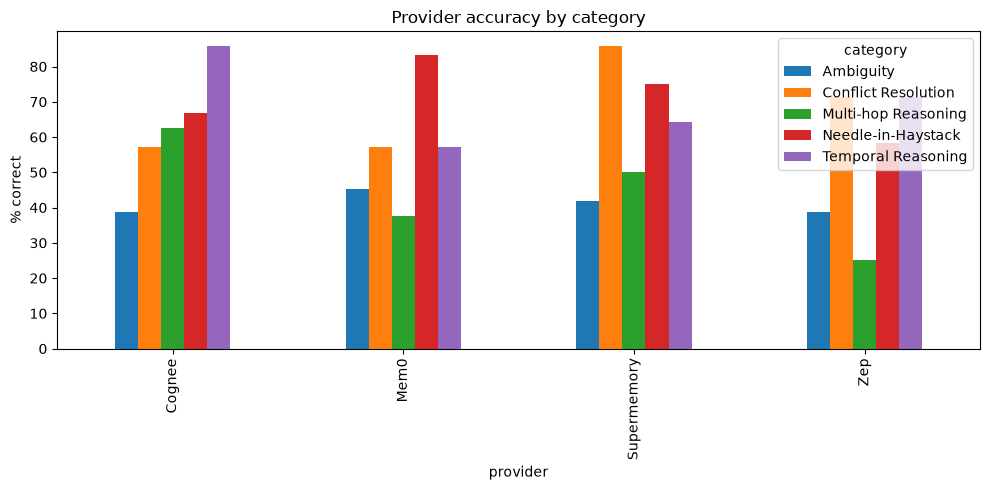

In [19]:
df = pd.DataFrame(results_log)
summary = df.groupby(["provider", "category"])["correct"].mean().mul(100).round(1).unstack()
display(summary)

summary.plot(kind="bar", figsize=(10, 5))
plt.ylabel("% correct")
plt.title("Provider accuracy by category")
plt.tight_layout()
plt.show()

## Final Comparison

**How to read this table** <br>
Each column is a different failure mode, not a general "quality" score, a high number means the provider is good at that *specific* thing, not necessarily anything else.

- *Ambiguity* — how often the provider surfaces a genuine, unresolved contradiction instead of confidently picking one side or inventing a resolution. Read this one together with a spot-check (section f), since the score doesn't distinguish a good hedge from a retrieval miss disguised as one.
- *Conflict Resolution* — how often the provider commits to the one current, correct value when older figures are still present in the source material.
- *Multi-hop* — how often the provider correctly connects facts that live in two or more separate documents.
- *Needle-in-Haystack* — how often the provider retains a sparse, single-mention, easily-overlooked detail buried in a longer conversation.
- *Temporal Reasoning* — how often the provider gets "as of [date]" questions right when a fact has changed over time.

**How to use this** <br>
Match the column to what your use case actually needs, and treat that column's leader as the strongest candidate for *that* need — not as an overall winner. 
- Temporal Reasoning: if your data involves facts that change over time (pricing, org changes, policy updates)
- Needle-in-Haystack: if your use case is long-running, low-signal conversation where small details matter
- Conflict Resolution: if a stale number reaching the user would actually cause harm 
- Multi-hop: if answers routinely require connecting separate document 
No provider should be expected to lead every column at once; if a single table shows one provider sweeping all five, treat that as a signal to check the run (rate limits, account tier changes, ingestion timing) before citing it, not as a finding.

**Caveats** <br>
Numbers shift a few points between runs from LLM sampling variance and each provider's own retrieval non-determinism, expected and not meaningful on its own. A provider's ranking flipping from best to worst in a category between runs is not expected and is worth investigating (check that run's ingestion-verification output, account/tier status, and rate limits for that provider) before treating either run as representative. Ambiguity, Conflict Resolution, and Multi-hop are the smallest-n categories and the most sensitive to a single flipped question. Also unchanged from run to run: one synthesis LLM (gpt-4o-mini) layered on top of every provider's retrieval, one fictional dataset (Solvane docs + 11 personas), and an LLM judge grading LLM-generated answers.